## Data exploration

In [1]:
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None
pd.options.display.float_format = '{:,.2f}'.format

In [2]:
df = pd.read_csv('orders.csv')
print(df.shape)
df.head()

(42900318, 9)


,id,timestamp,market,pair,side,quantity,price,order_type,execution_time
0,1,1733000400000165,BINANCE,ETH_USDT,ASK,0.32,368.45,Limit,7.28
1,2,1733000400000970,HUOBI,ADA_USDT,BID,0.55,188.06,Market,1.80
2,3,1733000400001831,KRAKEN,ADA_USDT,BID,0.77,552.32,Market,9.09
3,4,1733000400001953,KRAKEN,LTC_USDT,BID,0.21,975.90,Limit,2.88
4,5,1733000400002031,HUOBI,LTC_USDT,ASK,0.93,734.89,Market,0.44


In [3]:
# check for nulls 
df.isna().sum()

id                0
timestamp         0
market            0
pair              0
side              0
quantity          0
price             0
order_type        0
execution_time    0
dtype: int64

In [4]:
# convert data column to timestamp format
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='us')

In [5]:
# group by trading pair and market to find data loss periods if any
grouped = df.groupby(['pair', 'market'])

In [6]:
# function to find difference between two consecutive timestamps in each group
def find_data_loss(group):
    group = group.sort_values(by='timestamp')
    group['time_diff'] = group['timestamp'].diff()
    return group

In [7]:
# describe each group with some metrics
grouped = grouped.apply(find_data_loss).reset_index(drop=True)
grouped.groupby(['pair', 'market'])['time_diff'].describe()

count                       mean  \
pair     market                                        
ADA_USDT BINANCE  2860899  0 days 00:00:00.030200038   
         HUOBI    2856611  0 days 00:00:00.030245371   
         KRAKEN   2861828  0 days 00:00:00.030190234   
BTC_USDT BINANCE  2862633  0 days 00:00:00.030181727   
         HUOBI    2856564  0 days 00:00:00.030245861   
         KRAKEN   2863894  0 days 00:00:00.030168452   
ETH_USDT BINANCE  2861364  0 days 00:00:00.030195130   
         HUOBI    2858177  0 days 00:00:00.030228798   
         KRAKEN   2860974  0 days 00:00:00.030199240   
LTC_USDT BINANCE  2859422  0 days 00:00:00.030215631   
         HUOBI    2858907  0 days 00:00:00.030221080   
         KRAKEN   2860223  0 days 00:00:00.030207175   
XRP_USDT BINANCE  2861293  0 days 00:00:00.030195879   
         HUOBI    2859685  0 days 00:00:00.030212855   
         KRAKEN   2857829  0 days 00:00:00.030232479   

                                        std              min  \
pair     market                                                
ADA_USDT BINANCE  0 days 00:00:00.378063786  0 days 00:00:00   
         HUOBI    0 days 00:00:00.378336771  0 days 00:00:00   
         KRAKEN   0 days 00:00:00.378009093  0 days 00:00:00   
BTC_USDT BINANCE  0 days 00:00:00.377937315  0 days 00:00:00   
         HUOBI    0 days 00:00:00.378332784  0 days 00:00:00   
         KRAKEN   0 days 00:00:00.377869386  0 days 00:00:00   
ETH_USDT BINANCE  0 days 00:00:00.378038778  0 days 00:00:00   
         HUOBI    0 days 00:00:00.378231594  0 days 00:00:00   
         KRAKEN   0 days 00:00:00.378045475  0 days 00:00:00   
LTC_USDT BINANCE  0 days 00:00:00.378155798  0 days 00:00:00   
         HUOBI    0 days 00:00:00.378185241  0 days 00:00:00   
         KRAKEN   0 days 00:00:00.378120656  0 days 00:00:00   
XRP_USDT BINANCE  0 days 00:00:00.378034266  0 days 00:00:00   
         HUOBI    0 days 00:00:00.378133071  0 days 00:00:00   
         KRAKEN   0 days 00:00:00.378263344  0 days 00:00:00   

                                     25%                     50%  \
pair     market                                                    
ADA_USDT BINANCE  0 days 00:00:00.002279  0 days 00:00:00.005294   
         HUOBI    0 days 00:00:00.002285  0 days 00:00:00.005301   
         KRAKEN   0 days 00:00:00.002280  0 days 00:00:00.005291   
BTC_USDT BINANCE  0 days 00:00:00.002279  0 days 00:00:00.005294   
         HUOBI    0 days 00:00:00.002286  0 days 00:00:00.005302   
         KRAKEN   0 days 00:00:00.002274  0 days 00:00:00.005294   
ETH_USDT BINANCE  0 days 00:00:00.002281  0 days 00:00:00.005302   
         HUOBI    0 days 00:00:00.002283  0 days 00:00:00.005304   
         KRAKEN   0 days 00:00:00.002284  0 days 00:00:00.005299   
LTC_USDT BINANCE  0 days 00:00:00.002282  0 days 00:00:00.005303   
         HUOBI    0 days 00:00:00.002281  0 days 00:00:00.005297   
         KRAKEN   0 days 00:00:00.002284  0 days 00:00:00.005296   
XRP_USDT BINANCE  0 days 00:00:00.002281  0 days 00:00:00.005296   
         HUOBI    0 days 00:00:00.002282  0 days 00:00:00.005302   
         KRAKEN   0 days 00:00:00.002281  0 days 00:00:00.005301   

                                     75%                     max  
pair     market                                                   
ADA_USDT BINANCE  0 days 00:00:00.010670  0 days 00:10:00.775393  
         HUOBI    0 days 00:00:00.010694  0 days 00:10:00.758060  
         KRAKEN   0 days 00:00:00.010664  0 days 00:10:00.789913  
BTC_USDT BINANCE  0 days 00:00:00.010661  0 days 00:10:00.758336  
         HUOBI    0 days 00:00:00.010684  0 days 00:10:00.748888  
         KRAKEN   0 days 00:00:00.010666  0 days 00:10:00.786931  
ETH_USDT BINANCE  0 days 00:00:00.010680  0 days 00:10:00.792021  
         HUOBI    0 days 00:00:00.010689  0 days 00:10:00.752355  
         KRAKEN   0 days 00:00:00.010682  0 days 00:10:00.759827  
LTC_USDT BINANCE  0 days 00:00:00.010681  0 days 00:10:00.760635  
         HUOBI   

it is clear, that there is a 10 minute data loss in each group, let's research it more detailed for a single group:

pair: **BTC_USDT**

market: **BINANCE**

In [8]:
sample = grouped[(grouped['pair'] == 'BTC_USDT') & (grouped['market'] == 'BINANCE')]

In [9]:
sample['time_diff_seconds'] = sample['time_diff'].dt.total_seconds()

In [10]:
sample['minute'] = sample['timestamp'].dt.minute
sample['second'] = sample['timestamp'].dt.second

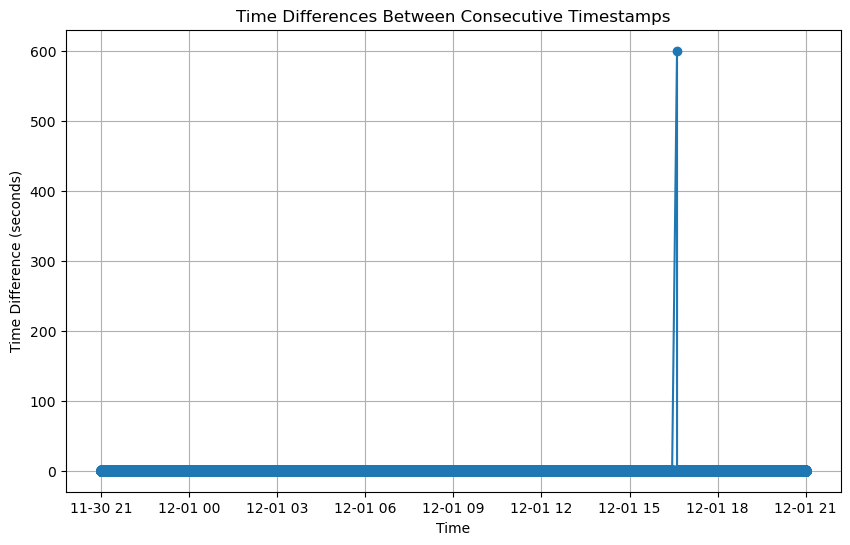

In [11]:
# Plot the time differences
plt.figure(figsize=(10, 6))
plt.plot(sample['timestamp'], sample['time_diff_seconds'], marker='o', linestyle='-')
plt.xlabel('Time')
plt.ylabel('Time Difference (seconds)')
plt.title('Time Differences Between Consecutive Timestamps')
plt.grid(True)
plt.show()

In [12]:
sample['time_diff_seconds'].max()

600.758336

there is a clear ~600 seconds stop in trading, let's check this out more detailed for each group

In [13]:
# row, where time_diff in seconds > 0
grouped[grouped['time_diff'].dt.seconds > 0]

,id,timestamp,market,pair,side,quantity,price,order_type,execution_time,time_diff
2335349,35111139,2024-12-01 16:37:02.002692,BINANCE,ADA_USDT,BID,0.66,94.10,Market,6.78,0 days 00:10:00.775393
5473519,39229323,2024-12-01 18:57:38.002244,HUOBI,ADA_USDT,BID,0.14,50.04,Limit,3.02,0 days 00:10:00.758060
7439946,26009831,2024-12-01 11:30:20.003622,KRAKEN,ADA_USDT,ASK,0.86,424.17,Limit,8.48,0 days 00:10:00.789913
10915567,35111137,2024-12-01 16:37:02.001800,BINANCE,BTC_USDT,BID,0.86,730.23,Market,8.00,0 days 00:10:00.758336
14054371,39229325,2024-12-01 18:57:38.003106,HUOBI,BTC_USDT,ASK,0.11,173.63,Limit,9.53,0 days 00:10:00.748888
16020151,26009828,2024-12-01 11:30:20.001198,KRAKEN,BTC_USDT,ASK,0.36,90.63,Limit,6.27,0 days 00:10:00.786931
19496900,35111178,2024-12-01 16:37:02.021786,BINANCE,ETH_USDT,BID,0.90,674.58,Limit,7.79,0 days 00:10:00.792021
22637232,39229327,2024-12-01 18:57:38.004833,HUOBI,ETH_USDT,BID,0.01,371.06,Market,1.35,0 days 00:10:00.752355
24605350,26009825,2024-12-01 11:30:20.000135,KRAKEN,ETH_USDT,BID,0.15,617.46,Limit,5.58,0 days 00:10:00.759827
28074523,35111142,2024-12-01 16:37:02.004343,BINANCE,LTC_USDT,ASK,0.74,841.09,Limit,3.62,0 days 00:10:00.760635


In [14]:
# timeseries for BINANCE, ADA_USDT, where time_tiff was 600 seconds
grouped.iloc[2335345:2335352]

,id,timestamp,market,pair,side,quantity,price,order_type,execution_time,time_diff
2335345,34910757,2024-12-01 16:27:01.211450,BINANCE,ADA_USDT,BID,0.36,450.58,Limit,2.97,0 days 00:00:00.016627
2335346,34910761,2024-12-01 16:27:01.213796,BINANCE,ADA_USDT,BID,0.51,916.73,Market,4.18,0 days 00:00:00.002346
2335347,34910765,2024-12-01 16:27:01.216783,BINANCE,ADA_USDT,ASK,0.37,734.22,Limit,2.29,0 days 00:00:00.002987
2335348,34910786,2024-12-01 16:27:01.227299,BINANCE,ADA_USDT,ASK,0.41,592.63,Limit,9.05,0 days 00:00:00.010516
2335349,35111139,2024-12-01 16:37:02.002692,BINANCE,ADA_USDT,BID,0.66,94.10,Market,6.78,0 days 00:10:00.775393
2335350,35111149,2024-12-01 16:37:02.007594,BINANCE,ADA_USDT,ASK,0.36,364.69,Market,4.04,0 days 00:00:00.004902
2335351,35111159,2024-12-01 16:37:02.011609,BINANCE,ADA_USDT,BID,0.34,375.05,Market,9.58,0 days 00:00:00.004015


there was stop/data loss in BINANCE trading from 16:27 -> 16:37 for approximately 600 seconds

In [15]:
data_loss_timings = grouped[grouped['time_diff'].dt.seconds > 0].\
    set_index('market').groupby('market')['timestamp'].sample(1).reset_index()


In [16]:
for i, row in data_loss_timings.iterrows():
    hour = row["timestamp"].hour
    minute = row["timestamp"].minute
    print(
        f'Stop in trading for {row["market"]}: {hour}:{minute-10} - {hour}:{minute}'
    )

Stop in trading for BINANCE: 16:27 - 16:37
Stop in trading for HUOBI: 18:47 - 18:57
Stop in trading for KRAKEN: 11:20 - 11:30


here is a data trading loss for each market

## Statistical Analysis

In [17]:
# let's take a sample of market-pair group to explore it for trade quantity or execution times outliers
sample = df[(df['pair'] == 'BTC_USDT') & (df['market'] == 'BINANCE')]

<Axes: xlabel='quantity', ylabel='Count'>

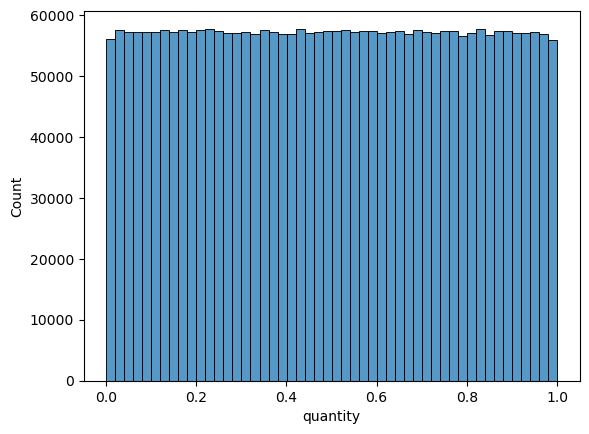

In [18]:
sns.histplot(sample['quantity'], bins=50)

quantity seems to have a uniform distribution, we can test it with a statistical kstest.

In [19]:
# we take sample, as stat test are sensitive to sample size and 
# even small deviations from uniformity can lead to the rejection of the null hypothesis.
sample_for_test = sample.sample(10000)
stats.kstest(sample_for_test['quantity'], 'uniform')

KstestResult(statistic=0.009599999999999997, pvalue=0.3133772471765358, statistic_location=0.407, statistic_sign=-1)

do not reject H_0 with 0.05 confidence level -> quantity has a uniform distribution. Let's check it for other groups.

In [20]:
uniform_cnt = 0
grouped = df.groupby(['pair', 'market'])
pairs = grouped['id'].count().index.to_list()
for pair, market in pairs:
    group = df[(df['pair'] == pair) & (df['market'] == market)]
    sample_for_test = group.sample(10000)
    p_val = stats.kstest(sample_for_test['quantity'], 'uniform').pvalue
    if p_val >= 0.05:
        uniform_cnt += 1

In [21]:
len(pairs), uniform_cnt

(15, 14)

quantity for each pair has uniform distribution

<Axes: xlabel='execution_time', ylabel='Count'>

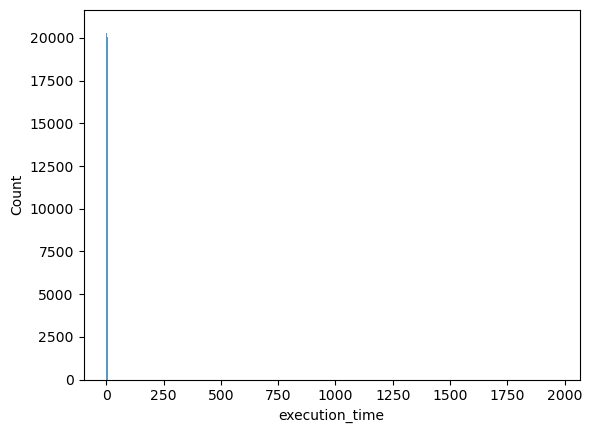

In [22]:
sns.histplot(sample['execution_time'])

there is a clear fact of having outliers

<Axes: xlabel='execution_time'>

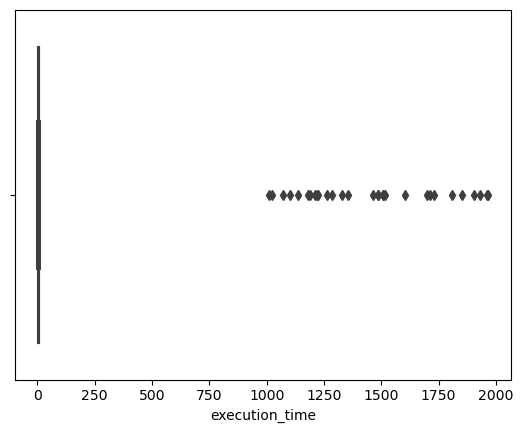

In [23]:
sns.boxplot(x=sample['execution_time'])

outliers starts from execution_time greater than 1000, let's explore how many outliers are there

In [24]:
uniform_cnt = 0
pairs = grouped['id'].count().index.to_list()
for pair, market in pairs:
    group = df[(df['pair'] == pair) & (df['market'] == market)]
    sample_for_test = group.sample(10000)
    p_val = stats.kstest(sample_for_test['quantity'], 'uniform').pvalue
    if p_val >= 0.05:
        uniform_cnt += 1

In [25]:
sample[sample['execution_time'] > 1000].shape

(30, 9)

<Axes: xlabel='execution_time'>

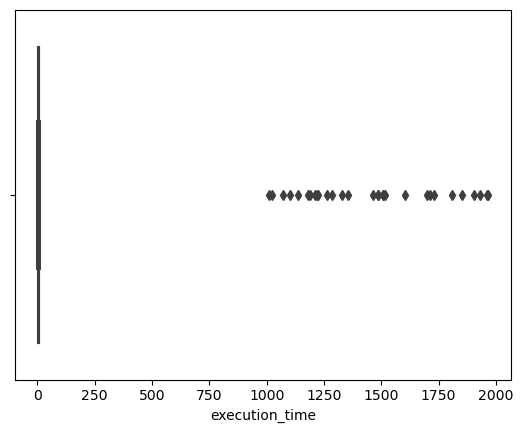

In [26]:
sns.boxplot(x=sample['execution_time'])

there are 30 rows with execution_time > 1000

<Axes: xlabel='execution_time', ylabel='Count'>

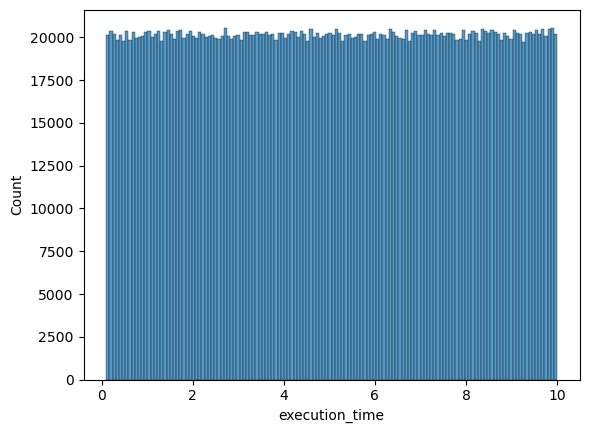

In [27]:
sample_cleared = sample[sample['execution_time'] < 1000]
sns.histplot(sample_cleared['execution_time'])

it seems that execution_time has also uniform distribution, let's check it with stat test for each group. We should normalize data, as in kstest it compares with Uniform(0, 1) distribution

In [28]:
uniform_cnt = 0
pairs = grouped['id'].count().index.to_list()
for pair, market in pairs:
    group = df[(df['pair'] == pair) & (df['market'] == market)]
    print(f'There are {group[group["execution_time"] > 1000].shape[0]} outliers for market {market} and pair {pair}')
    group = group[group['execution_time'] < 1000]
    sample_for_test = group.sample(10000)
    sample_for_test['execution_time'] = \
        (sample_for_test['execution_time'] - sample_for_test['execution_time'].min()) /\
            (sample_for_test['execution_time'].max() - sample_for_test['execution_time'].min())
    p_val = stats.kstest(sample_for_test['execution_time'], 'uniform').pvalue
    if p_val >= 0.05:
        uniform_cnt += 1

There are 41 outliers for market BINANCE and pair ADA_USDT
There are 38 outliers for market HUOBI and pair ADA_USDT
There are 35 outliers for market KRAKEN and pair ADA_USDT
There are 30 outliers for market BINANCE and pair BTC_USDT
There are 32 outliers for market HUOBI and pair BTC_USDT
There are 33 outliers for market KRAKEN and pair BTC_USDT
There are 36 outliers for market BINANCE and pair ETH_USDT
There are 46 outliers for market HUOBI and pair ETH_USDT
There are 31 outliers for market KRAKEN and pair ETH_USDT
There are 34 outliers for market BINANCE and pair LTC_USDT
There are 27 outliers for market HUOBI and pair LTC_USDT
There are 31 outliers for market KRAKEN and pair LTC_USDT
There are 29 outliers for market BINANCE and pair XRP_USDT
There are 23 outliers for market HUOBI and pair XRP_USDT
There are 34 outliers for market KRAKEN and pair XRP_USDT


In [29]:
len(pairs), uniform_cnt

(15, 15)

execution_time for each group has uniform distribution

In [30]:
# remove detected outliers
df = df[df['execution_time'] < 1000]

In [31]:
# Compute the average trade quantity and build a distribution of execution time per market (take care of outliers)

df.groupby(['market'])['quantity'].mean()

market
BINANCE   0.50
HUOBI     0.50
KRAKEN    0.50
Name: quantity, dtype: float64

In [32]:
df['quantity'].mean()

0.5004429923921814

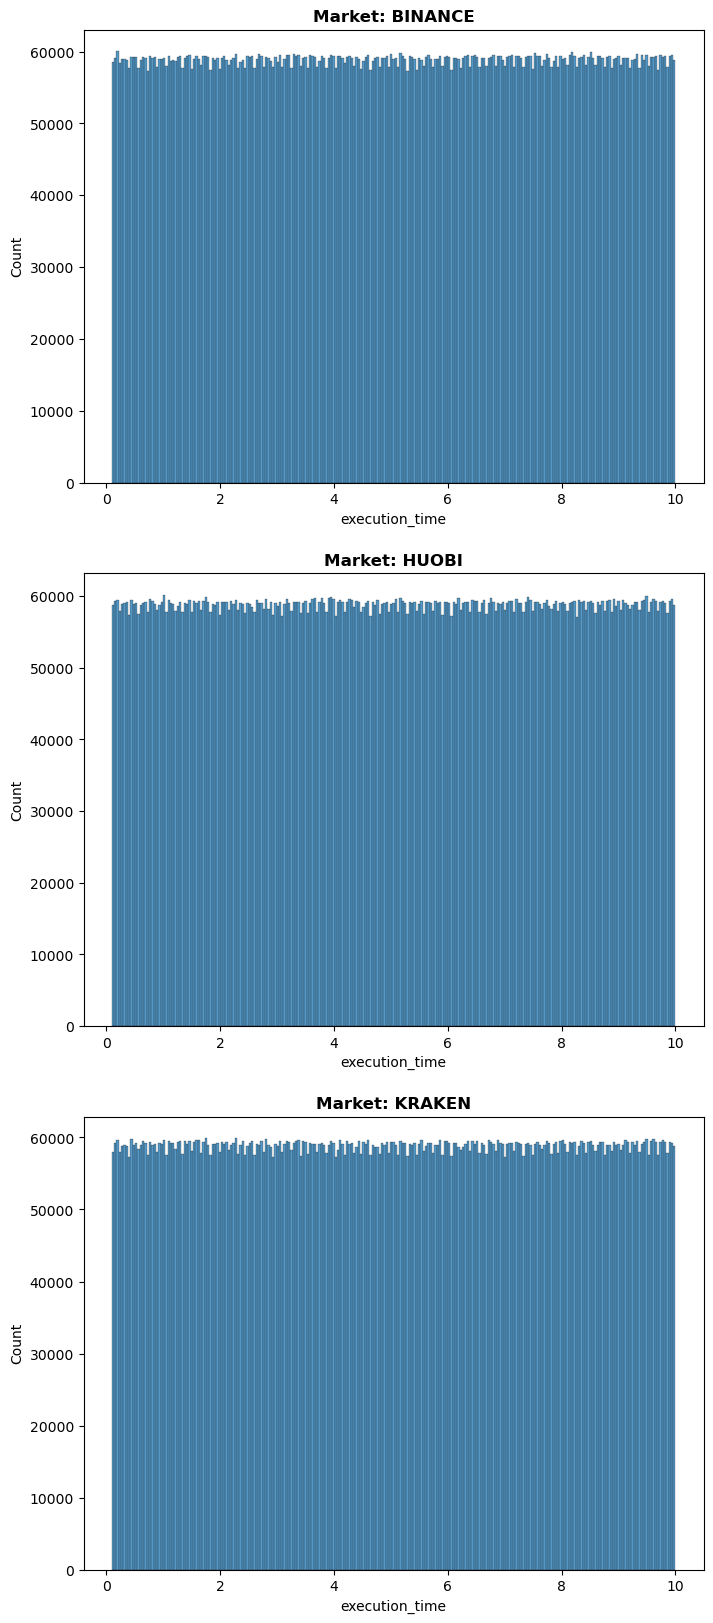

In [33]:
fig, axs = plt.subplots(3, 1, figsize=(8, 20))

pairs = grouped['id'].count().index.to_list()
for i, market in enumerate(df['market'].unique().tolist()):
    group = df[(df['market'] == market)]
    sns.histplot(group['execution_time'], ax=axs[i])
    axs[i].set_title(f'Market: {market}', weight='bold')

In [34]:
# Process trade data to aggregate 10-minute OHLC (Open, High, Low, Close) candlesticks 
# grouped by trading pair and market. Include the total traded volume for each interval alongside OHLC values. 

In [35]:
df_sorted = df.set_index('timestamp').sort_index()
ohlc = df_sorted.groupby(['market', 'pair'])['price'].resample('10Min').ohlc()
total_volume = df_sorted.groupby(['market', 'pair'])['price'].resample('10Min').sum()
resampled = pd.concat([ohlc, total_volume], axis=1).rename(columns={'price': 'total_volume'})
resampled = resampled.reset_index()
resampled.head()

,market,pair,timestamp,open,high,low,close,total_volume
0,BINANCE,ADA_USDT,2024-11-30 21:00:00,612.89,999.87,0.10,172.08,"9,836,670.61"
1,BINANCE,ADA_USDT,2024-11-30 21:10:00,255.88,999.97,0.20,221.24,"9,974,285.21"
2,BINANCE,ADA_USDT,2024-11-30 21:20:00,24.45,999.94,0.16,37.43,"10,096,542.35"
3,BINANCE,ADA_USDT,2024-11-30 21:30:00,711.27,999.95,0.13,56.17,"10,042,042.73"
4,BINANCE,ADA_USDT,2024-11-30 21:40:00,725.60,999.97,0.13,914.28,"10,010,440.41"


<Axes: xlabel='price', ylabel='Count'>

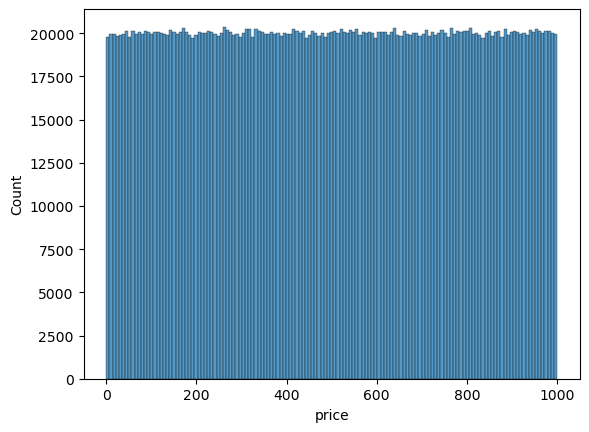

In [36]:
sample = df[(df['pair'] == 'BTC_USDT') & (df['market'] == 'BINANCE')]
sns.histplot(sample['price'])

as there is a uniform distribution for price column (dataset generated randomly), we don't see any logic in high-low values, as well as open close in consecutive rows

## A/B testing

$M_1$ - Median of execution time in market orders

$M_2$ - Median of execution time in limit orders

$H_0: M_1 = M_2$

$H_A: M_1 \ne M_2$


In [37]:
market_orders = df[df['order_type'] == 'Market']['execution_time']
limit_orders = df[df['order_type'] == 'Limit']['execution_time']

median_market = market_orders.median()
median_limit = limit_orders.median()

print(f"Median Execution Time for Market Orders: {median_market}")
print(f"Median Execution Time for Limit Orders: {median_limit}")

Median Execution Time for Market Orders: 5.053
Median Execution Time for Limit Orders: 5.051


In [38]:
# Use Mann-Whitney U Test
stat, p_value = stats.mannwhitneyu(
    market_orders, 
    limit_orders, 
    alternative='two-sided'
)

print(f"Mann-Whitney U Test Statistic: {stat}")
print(f"P-value: {p_value}")

Mann-Whitney U Test Statistic: 230102589147933.0
P-value: 0.18882019653540594


In [39]:
# Use 5% confidence level
alpha = 0.05
if p_value < alpha:
    print("The difference in execution times is statistically significant.")
else:
    print("The difference in execution times is not statistically significant.")

The difference in execution times is not statistically significant.


So we hold with $H_0$, assuming that medians are equal